In [13]:
# 1.1 Import des packages de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb


# Affichage dans Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,5)


# Pour afficher toutes les lignes et colonnes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# (Optionnel) pour éviter les coupures de texte dans les cellules
pd.set_option('display.max_colwidth', None)


df_treated= pd.read_csv("data_ready_to_use.csv")


In [14]:
from sklearn.model_selection import train_test_split

# Colonnes de la première partie
first_part_cols = df_treated.columns[:26]

# Target
target_col = 'LIT_002_FILTER_WATER_STG_TNK'

# Features : toutes les colonnes sauf la target
feature_cols = [col for col in first_part_cols if col != target_col]

# Préparer X et Y
X = df_treated[feature_cols].copy()
y = df_treated[target_col].copy()

# Split en train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Vérification
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (359201, 25)
X_test shape: (89801, 25)
y_train shape: (359201,)
y_test shape: (89801,)


In [15]:
# 1️⃣ Régression linéaire
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [16]:
# 2️⃣ Ridge Regression
ridge = Ridge()
params_ridge = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}
grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
y_pred_ridge = grid_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)


In [17]:

# 3️⃣ Lasso Regression
lasso = Lasso(max_iter=5000)
params_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)
y_pred_lasso = grid_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [18]:
# Affichage des résultats
print("=== Résultats ===")
print(f"Linear Regression : MSE={mse_lr:.4f}, R2={r2_lr:.4f}")
print(f"Ridge (best alpha={grid_ridge.best_params_['alpha']}) : MSE={mse_ridge:.4f}, R2={r2_ridge:.4f}")
print(f"Lasso (best alpha={grid_lasso.best_params_['alpha']}) : MSE={mse_lasso:.4f}, R2={r2_lasso:.4f}")

=== Résultats ===
Linear Regression : MSE=70.7692, R2=0.3463
Ridge (best alpha=1) : MSE=70.7692, R2=0.3463
Lasso (best alpha=0.001) : MSE=70.7690, R2=0.3463


In [19]:
# Choix du meilleur modèle 
r2_scores = {'Linear': r2_lr, 'Ridge': r2_ridge, 'Lasso': r2_lasso}
best_model_name = max(r2_scores, key=r2_scores.get)
print(f"✅ Meilleur modèle : {best_model_name}")

✅ Meilleur modèle : Lasso


In [20]:
# Meilleur modèle
best_ridge = grid_ridge.best_estimator_

# Évaluation sur le test set
mse_test = mean_squared_error(y_test, best_ridge.predict(X_test))
r2_test = r2_score(y_test, best_ridge.predict(X_test))

print(f"Score du meilleur modèle (R²) : {r2_test:.4f}")
print(f"Erreur MSE sur test set : {mse_test:.4f}")


Score du meilleur modèle (R²) : 0.3463
Erreur MSE sur test set : 70.7692


In [22]:
results = {}

# 1️⃣ Random Forest
rf = RandomForestRegressor(random_state=42)
params_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
grid_rf = GridSearchCV(rf, params_rf, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.predict(X_test)

results['Random Forest'] = {
    'Best Params': grid_rf.best_params_,
    'R2': r2_score(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf)
}

In [25]:
# 2️⃣ Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
params_gb = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate':[0.05,0.1]}
grid_gb = GridSearchCV(gb, params_gb, cv=3, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
y_pred_gb = grid_gb.predict(X_test)

results['Gradient Boosting'] = {
    'Best Params': grid_gb.best_params_,
    'R2': r2_score(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb)
}


In [28]:
# 3️⃣ XGBoost
xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
params_xgb = {'n_estimators':[50,100], 'max_depth':[3,5], 'learning_rate':[0.05,0.1]}
grid_xgb = GridSearchCV(xgbr, params_xgb, cv=3, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
y_pred_xgb = grid_xgb.predict(X_test)

results['XGBoost'] = {
    'Best Params': grid_xgb.best_params_,
    'R2': r2_score(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'MAE': mean_absolute_error(y_test, y_pred_xgb)
}

In [30]:


# Affichage
for model, metrics in results.items():
    print(f"=== {model} ===")
    for k,v in metrics.items():
        if isinstance(v,float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")
    print()





=== Random Forest ===
Best Params: {'max_depth': None, 'n_estimators': 100}
R2: 0.9597
MSE: 4.3678
RMSE: 2.0899
MAE: 1.1657

=== Gradient Boosting ===
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
R2: 0.6751
MSE: 35.1729
RMSE: 5.9307
MAE: 4.3681

=== XGBoost ===
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
R2: 0.6772
MSE: 34.9515
RMSE: 5.9120
MAE: 4.3568



In [45]:
import joblib

# 1. Récupération du meilleur modèle (déjà entraîné)
best_rf_model = grid_rf.best_estimator_

print("Le modèle sauvegardé a ces paramètres :")
print(grid_rf.best_params_)

# 2. Sauvegarde immédiate
# On sauvegarde le modèle ET le scaler (toujours indispensable)
joblib.dump(best_rf_model, 'best_model_rf.pkl')

print("✅ Sauvegarde terminée : 'best_model_rf.pkl' est prêt.")

Le modèle sauvegardé a ces paramètres :
{'max_depth': None, 'n_estimators': 100}


NameError: name 'scaler' is not defined

In [47]:
import joblib

print("Sauvegarde des meilleurs modèles en cours (SANS Scaler)...")

# 1. Sauvegarde du Random Forest (Le grand gagnant)
try:
    # On sauvegarde le meilleur estimateur trouvé par le GridSearch
    joblib.dump(grid_rf.best_estimator_, 'modele_rf_opti.pkl')
    print(f"✅ Random Forest sauvegardé : 'modele_rf_opti.pkl'")
except NameError:
    print("⚠️ Attention : La variable 'grid_rf' n'a pas été trouvée en mémoire.")

# 2. Sauvegarde du Gradient Boosting
try:
    joblib.dump(grid_gb.best_estimator_, 'modele_gb_opti.pkl')
    print(f"✅ Gradient Boosting sauvegardé : 'modele_gb_opti.pkl'")
except NameError:
    print("⚠️ Attention : La variable 'grid_gb' n'a pas été trouvée.")

# 3. Sauvegarde du XGBoost
try:
    joblib.dump(grid_xgb.best_estimator_, 'modele_xgb_opti.pkl')
    print(f"✅ XGBoost sauvegardé : 'modele_xgb_opti.pkl'")
except NameError:
    print("⚠️ Attention : La variable 'grid_xgb' n'a pas été trouvée.")

print("\nTerminé ! Vous pouvez maintenant fermer le notebook.")
print("Rappel : Lors du chargement pour la prédiction, vous passerez directement les données brutes (pas de transform).")

Sauvegarde des meilleurs modèles en cours...
✅ Random Forest sauvegardé : 'modele_rf_opti.pkl'
✅ Gradient Boosting sauvegardé : 'modele_gb_opti.pkl'
✅ XGBoost sauvegardé : 'modele_xgb_opti.pkl'


NameError: name 'scaler' is not defined

In [3]:
import joblib
import pandas as pd
import numpy as np

# --- 1. CHARGEMENT DU MODÈLE SEUL ---
print("Chargement du modèle...")
try:
    # On charge juste le modèle
    model = joblib.load('modele_gb_opti.pkl') 
    print("✅ Modèle chargé.")
except FileNotFoundError:
    print("❌ Erreur : Fichier .pkl introuvable.")
    exit()

# --- 2. DÉFINITION DES INPUTS (Données Brutes) ---
# Attention : L'ordre des colonnes doit être STRICTEMENT le même que dans 'X' lors de l'entraînement
# Voici vos colonnes basées sur votre code précédent
colonnes_entrainement = [
    'INTAKE LINE PRESSURE OF HMMF FEED PUMPS', 
    'FIT_001A_FLOW AT INLET HMMF-A', 'FIT_001B_FLOW AT INLET HMMF-B', 
    'FIT_001C_FLOW AT INLET HMMF-C', 'FIT_001D_FLOW AT INLET HMMF-D', 
    'FIT_001E_FLOW AT INLET HMMF-E', 'FIT_001F_FLOW AT INLET HMMF-F', 
    'FIT_001G_FLOW AT INLET HMMF-G', 'FIT_001H_FLOW AT INLET HMMF-H', 
    'FIT_001I_FLOW AT INLET HMMF-I', 'FIT_001J_FLOW AT INLET HMMF-J', 
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B', 
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D', 
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F', 
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H', 
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J', 
    'PIT_001 DISCHARGE PRESSURE AT HMMF A-E', 'PIT_001 DISCHARGE PRESSURE AT HMMF F-J',
    'LIT_002_FILTER_WATER_STG_TNK', 'BACKWASH PUMP FLOW' # Vérifiez si vous aviez inclus ces colonnes dans X
]
# NOTE IMPORTANTE : Dans votre code 'first_part_cols[:26]', vérifiez quelles colonnes exactes sont dans X.
# Si vous avez exclu la target 'LIT_002...', ne la mettez pas ici.
# Je suppose ici que X contient tout SAUF la target.

inputs_utilisateur = {
    # Pression d'entrée
    'INTAKE LINE PRESSURE OF HMMF FEED PUMPS': 3.5, 

    # Débits (Exemple)
    'FIT_001A_FLOW AT INLET HMMF-A': 250.0,
    # ... (Ajoutez les autres FIT B à J ici) ...
    'FIT_001J_FLOW AT INLET HMMF-J': 250.0,

    # Pressions Différentielles
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A': 0.45, 
    # ... (Ajoutez les autres PDIT B à J ici) ...
    'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J': 0.40,

    # Refoulement
    'PIT_001 DISCHARGE PRESSURE AT HMMF A-E': 2.8,
    'PIT_001 DISCHARGE PRESSURE AT HMMF F-J': 2.8
    
    # Ajoutez les colonnes manquantes pour arriver au même nombre que lors de l'entraînement
}

# --- 3. PRÉPARATION ---
# On crée un DataFrame avec une seule ligne
# Astuce : Pour éviter les erreurs de colonnes manquantes, on remplit tout à 0 d'abord
# puis on met vos valeurs.
# Dans l'idéal, il faut récupérer 'model.feature_names_in_' si c'est un RandomForest récent

try:
    cols_attendues = model.feature_names_in_
except AttributeError:
    # Si le modèle n'a pas gardé les noms, on utilise votre liste manuelle
    cols_attendues = colonnes_entrainement

# On crée un DF vide avec les bonnes colonnes
df_input = pd.DataFrame(columns=cols_attendues)
df_input.loc[0] = 0.0 # Initialise à 0

# On remplit avec vos valeurs (les colonnes doivent avoir le même nom exact)
for col, val in inputs_utilisateur.items():
    if col in df_input.columns:
        df_input.at[0, col] = val

print("\nInputs prêts (Aperçu) :")
print(df_input.iloc[:, :5]) 

# --- 4. PRÉDICTION (Directe, sans scaler) ---
niveau_predit = model.predict(df_input)[0]

# --- 5. RÉSULTAT ---
print("\n" + "="*40)
print(f"🔮 PRÉDICTION IA (Random Forest / XGBoost)")
print("="*40)
print(f"Niveau estimé du Tank LIT_002 : {niveau_predit:.2f} %")

# Logique de décision
if niveau_predit > 70:
    print("🟢 STOCK CONFORTABLE : Backwash Autorisé.")
elif niveau_predit < 40:
    print("🔴 STOCK CRITIQUE : Backwash Interdit.")
else:
    print("🟠 STOCK MOYEN : Surveillance requise.")

Chargement du modèle...
✅ Modèle chargé.

Inputs prêts (Aperçu) :
   INTAKE LINE PRESSURE OF HMMF FEED PUMPS  FIT_001A_FLOW AT INLET HMMF-A  \
0                                      3.5                          250.0   

   FIT_001B_FLOW AT INLET HMMF-B  FIT_001C_FLOW AT INLET HMMF-C  \
0                            0.0                            0.0   

   FIT_001D_FLOW AT INLET HMMF-D  
0                            0.0  

🔮 PRÉDICTION IA (Random Forest / XGBoost)
Niveau estimé du Tank LIT_002 : 73.03 %
🟢 STOCK CONFORTABLE : Backwash Autorisé.


In [ ]:
from sklearn.model_selection import train_test_split

# 1️⃣ Select first part of columns
selected_columns = df_treated.columns[:26]

# 2️⃣ Target column
target_column = 'LIT_002_FILTER_WATER_STG_TNK'

# 3️⃣ Features (all except target)
feature_columns = [col for col in selected_columns if col != target_column]

# 4️⃣ Prepare features and target
X_data = df_treated[feature_columns].copy()
y_data = df_treated[target_column].copy()

# 5️⃣ Optional: create category for stratified split (zero vs non-zero)
y_category = (y_data.values != 0).astype(int)

# 6️⃣ Train/test split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_category
)

# 7️⃣ Verification
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1️⃣ Ridge Regression with Grid Search
ridge_model = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}

grid_ridge = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

# 2️⃣ Predictions
y_pred_ridge = grid_ridge.predict(X_test)

# 3️⃣ Evaluation
ridge_results = {
    'Best Params': grid_ridge.best_params_,
    'R2': r2_score(y_test, y_pred_ridge),
    'MSE': mean_squared_error(y_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'MAE': mean_absolute_error(y_test, y_pred_ridge)
}

print(ridge_results)


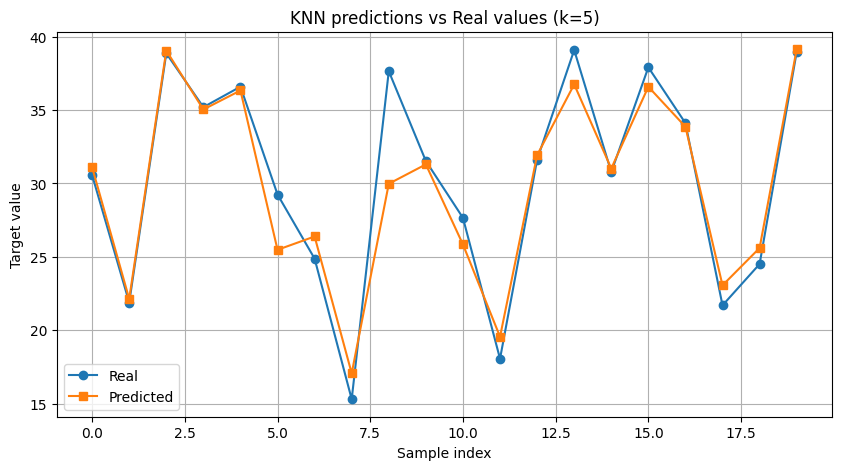

             Real  Predicted
401623  30.562500  31.096250
401767  21.887501  22.131250
17024   38.862499  39.048750
16981   35.193748  35.036250
16975   36.587502  36.330000
401642  29.243750  25.477500
403564  24.875000  26.385000
401810  15.300000  17.063750
403572  37.643749  29.975000
401613  31.525000  31.296250
401667  27.656250  25.842500
401790  18.056250  19.553749
401567  31.612499  31.922500
64818   39.087502  36.746250
401621  30.768749  31.015000
107261  37.906250  36.583750
401533  34.106251  33.859999
401768  21.693750  23.057500
401718  24.506250  25.600000
70039   38.950001  39.140001


In [93]:
import matplotlib.pyplot as plt

# Show first 20 points
plt.figure(figsize=(10,5))
plt.plot(range(20), y_test[:20], marker='o', label='Real')
plt.plot(range(20), y_pred_test[:20], marker='s', label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Target value')
plt.title(f'KNN predictions vs Real values (k={k})')
plt.legend()
plt.grid(True)
plt.show()

# Optional: print a small table
import pandas as pd
df_compare = pd.DataFrame({
    'Real': y_test[:20],
    'Predicted': y_pred_test[:20]
})
print(df_compare)


In [4]:
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Prepare X, y
first_part_cols = df_treated.columns[:26]
target_col = 'LIT_002_FILTER_WATER_STG_TNK'
feature_cols = [col for col in first_part_cols if col != target_col]

X = df_treated[feature_cols].copy()
y = df_treated[target_col].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Metrics lists
k_values = [1, 3, 5, 7, 9]
r2_train, r2_test = [], []
rmse_train, rmse_test = [], []
mae_train, mae_test = [], []

for k in tqdm(k_values, desc="KNN progress"):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    
    y_pred_train = np.clip(pipe.predict(X_train), 0, None)
    y_pred_test = np.clip(pipe.predict(X_test), 0, None)
    
    r2_train.append(r2_score(y_train, y_pred_train))
    r2_test.append(r2_score(y_test, y_pred_test))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    mae_test.append(mean_absolute_error(y_test, y_pred_test))


KNN progress: 100%|█████████████████████████████████████████████████████████████████████| 5/5 [39:21<00:00, 472.25s/it]



=== RESULTS ===
k = 1  | Train R² = 0.9390 | Test R² = 0.5610 | Train RMSE = 0.25 | Test RMSE = 0.67 | Train MAE = 0.00 | Test MAE = 0.02
k = 3  | Train R² = 0.8140 | Test R² = 0.6685 | Train RMSE = 0.44 | Test RMSE = 0.58 | Train MAE = 0.01 | Test MAE = 0.02
k = 5  | Train R² = 0.7574 | Test R² = 0.6724 | Train RMSE = 0.50 | Test RMSE = 0.58 | Train MAE = 0.02 | Test MAE = 0.02
k = 7  | Train R² = 0.7111 | Test R² = 0.6597 | Train RMSE = 0.54 | Test RMSE = 0.59 | Train MAE = 0.02 | Test MAE = 0.02
k = 9  | Train R² = 0.6827 | Test R² = 0.6471 | Train RMSE = 0.57 | Test RMSE = 0.60 | Train MAE = 0.02 | Test MAE = 0.02


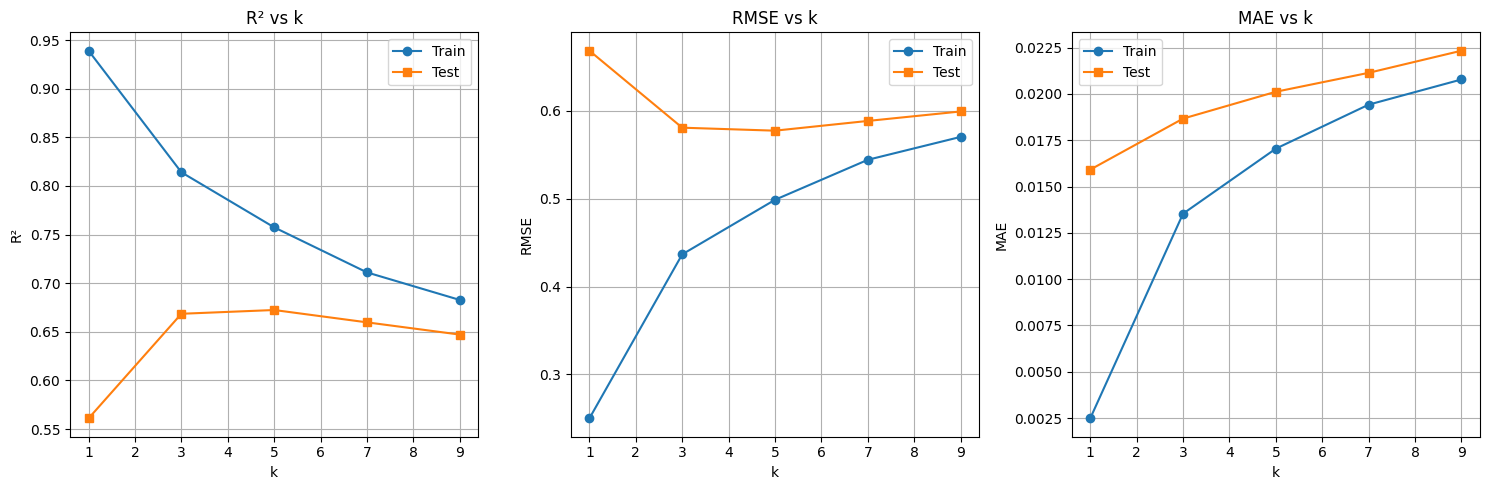

In [7]:


# ================= RESULTS TABLE ==================
print("\n=== RESULTS ===")
for i, k in enumerate(k_values):
    print(
        f"k = {k:<2} | "
        f"Train R² = {r2_train[i]:.4f} | Test R² = {r2_test[i]:.4f} | "
        f"Train RMSE = {rmse_train[i]:.2f} | Test RMSE = {rmse_test[i]:.2f} | "
        f"Train MAE = {mae_train[i]:.2f} | Test MAE = {mae_test[i]:.2f}"
    )

# ================= PLOTTING ==================
plt.figure(figsize=(15,5))

# R2
plt.subplot(1,3,1)
plt.plot(k_values, r2_train, '-o', label="Train")
plt.plot(k_values, r2_test, '-s', label="Test")
plt.title("R² vs k")
plt.xlabel("k")
plt.ylabel("R²")
plt.legend()
plt.grid()

# RMSE
plt.subplot(1,3,2)
plt.plot(k_values, rmse_train, '-o', label="Train")
plt.plot(k_values, rmse_test, '-s', label="Test")
plt.title("RMSE vs k")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.legend()
plt.grid()

# MAE
plt.subplot(1,3,3)
plt.plot(k_values, mae_train, '-o', label="Train")
plt.plot(k_values, mae_test, '-s', label="Test")
plt.title("MAE vs k")
plt.xlabel("k")
plt.ylabel("MAE")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
